# OFEV nested zip reader (station 2170)

This notebook scans the full nested archive recursively, extracts all files for station **2170**, parses PQPREVI time series, and plots model forecasts at lead times **6h, 12h, 24h, 48h**.

For ensemble-like model names, members are plotted together under the same base model label.

In [1]:
from __future__ import annotations

import re, zipfile
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

ZIP_PATH = Path(r"C:\Users\simon\Documents\DP\analysis\data\Data Fornisseurs\OFEV_model\swisstransfer_e4eb4e12-cd87-4d66-be08-4bd5ea69dadf.zip")
STATION_ID = "2170"
LEAD_TIMES = [6, 12, 24, 36, 48]
OUT_DIR = Path("../outputs/OFEV_probabilistic").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Archive not found: {ZIP_PATH}")

In [2]:
ROW_RE = re.compile(r"^\s*(\d{2})\s+(\d{2})\s+(\d{4})\s+(\d{2})\s+([-+]?\d+(?:[.,]\d+)?)\s+([-+]?\d+(?:[.,]\d+)?)\s*$")
NUM_RE = re.compile(r"^[-+]?\d+(?:[.,]\d+)?$")


def iter_nested_files(zf: zipfile.ZipFile, prefix: str = ""):
    """Yield (virtual_path, raw_bytes) for every file in nested zip trees."""
    for info in zf.infolist():
        if info.is_dir():
            continue
        name, raw = info.filename, zf.read(info)
        vpath = f"{prefix}{name}"
        if name.lower().endswith(".zip"):
            try:
                with zipfile.ZipFile(BytesIO(raw)) as nested:
                    yield from iter_nested_files(nested, vpath + "::")
            except zipfile.BadZipFile:
                pass
        else:
            yield vpath, raw


def model_from_filename(vpath: str) -> str | None:
    name = Path(vpath.split("::")[-1]).name
    m = re.match(rf"Pqprevi_(.+?)_{STATION_ID}(?:\.[A-Za-z0-9]+)?$", name)
    return m.group(1) if m else None


def parse_issue_time(vpath: str, text: str) -> pd.Timestamp | pd.NaT:
    """Prefer issue time in header; fallback to timestamp in folder name."""
    m = re.search(r"(?:Emission:|Ausgegeben am.*?:)\s*(\d{1,2})\.(\d{1,2})\.(\d{4}),\s*(\d{1,2})[.:](\d{2})", text)
    if m:
        d, mo, y, hh, mm = m.groups()
        return pd.Timestamp(f"{y}-{int(mo):02d}-{int(d):02d} {int(hh):02d}:{mm}:00")
    m = re.search(r"(20\d{2})(\d{2})(\d{2})[-_]?(\d{2})(\d{2})", vpath) or re.search(r"(20\d{2})(\d{2})(\d{2})(\d{2})", vpath)
    if not m:
        return pd.NaT
    y, mo, d, hh = m.groups()[:4]
    mm = m.groups()[4] if len(m.groups()) > 4 else "00"
    return pd.Timestamp(f"{y}-{mo}-{d} {hh}:{mm}:00")


def _f(x: str) -> float:
    try:
        return float(str(x).replace(",", "."))
    except Exception:
        return np.nan


def _pick(cols: list[str], *keys: str) -> str | None:
    cl = {c.lower(): c for c in cols}
    for k in keys:
        for lk, c in cl.items():
            if k in lk:
                return c
    return None


def read_tables(vpath: str, text: str, model: str, issue: pd.Timestamp):
    """Return deterministic rows and ensemble-wide rows from one OFEV file."""
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    if not lines:
        return [], []

    i = next((k for k, ln in enumerate(lines) if re.search(r"\bdd\s+mm\s+yyyy\s+hh\b", ln, re.I)), None)
    if i is None:
        rows = []
        for ln in lines:
            m = ROW_RE.match(ln)
            if not m:
                continue
            dd, mm, yyyy, hh, h, q = m.groups()
            vt = pd.Timestamp(f"{yyyy}-{mm}-{dd} {hh}:00:00")
            lt = int(round((vt - issue).total_seconds() / 3600))
            if lt in LEAD_TIMES and lt >= 0:
                rows.append({"model": model, "issue_time": issue, "valid_time": vt, "lead_time_h": lt, "H": _f(h), "Q": _f(q), "source_path": vpath})
        return rows, []

    head = re.split(r"\s+", lines[i])
    if len(head) < 6:
        return [], []
    base, cols = ["dd", "mm", "yyyy", "hh"], head[4:]

    # Ensemble files expose columns like H_ctl/H_e01... and Q_ctl/Q_e01... + Q_min..Q_max.
    is_ensemble = any(re.fullmatch(r"[HQ]_(ctl|e\d{2}|min|p25|p50|p75|max)", c, flags=re.I) for c in cols)
    h_col = _pick(cols, "wasserstand", "niveau", "h")
    q_col = _pick(cols, "abfluss", "debit", "dbit", "débit", "débits", "q")

    det, ens = [], []
    for ln in lines[i + 1 :]:
        toks = re.split(r"\s+", ln)
        if len(toks) < 4 + len(cols) or not all(NUM_RE.match(t) for t in toks[:4]):
            continue
        row = dict(zip(base + cols, toks[: 4 + len(cols)]))
        vt = pd.Timestamp(f"{row['yyyy']}-{row['mm']}-{row['dd']} {row['hh']}:00:00")
        lt = int(round((vt - issue).total_seconds() / 3600))
        if lt not in LEAD_TIMES or lt < 0:
            continue

        if is_ensemble:
            # Keep all member/stat columns exactly as provided (H_ctl..Q_max).
            ens.append({
                "model": model,
                "issue_time": issue,
                "valid_time": vt,
                "lead_time_h": lt,
                "source_path": vpath,
                **{c: _f(row.get(c, np.nan)) for c in cols},
            })
        else:
            det.append({
                "model": model,
                "issue_time": issue,
                "valid_time": vt,
                "lead_time_h": lt,
                "H": _f(row.get(h_col, np.nan)) if h_col else np.nan,
                "Q": _f(row.get(q_col, np.nan)) if q_col else np.nan,
                "source_path": vpath,
            })
    return det, ens


def _df(rows: list[dict], cols: list[str]) -> pd.DataFrame:
    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=cols)


det_rows, ens_rows = [], []
with zipfile.ZipFile(ZIP_PATH) as zf:
    for vpath, raw in iter_nested_files(zf):
        name = Path(vpath.split("::")[-1]).name
        if f"_{STATION_ID}" not in name or "Pqprevi_" not in name:
            continue
        model = model_from_filename(vpath)
        if not model:
            continue
        text = raw.decode("utf-8", errors="ignore")
        issue = parse_issue_time(vpath, text)
        if pd.isna(issue):
            continue
        d, e = read_tables(vpath, text, model, issue)
        det_rows.extend(d)
        ens_rows.extend(e)

if not det_rows and not ens_rows:
    raise RuntimeError(f"No station {STATION_ID} data found")

# 1) Deterministic DF (files with simple H/Q columns)
df_det = _df(det_rows, ["model", "issue_time", "valid_time", "lead_time_h", "H", "Q", "source_path"])\
    .sort_values(["lead_time_h", "issue_time", "model"], na_position="last")\
    .reset_index(drop=True)

# 2) Ensemble/member DF (rows with columns like H_ctl...Q_max)
df_ens = _df(ens_rows, ["model", "issue_time", "valid_time", "lead_time_h", "source_path"])\
    .sort_values(["lead_time_h", "issue_time", "model"], na_position="last")\
    .reset_index(drop=True)

# 3) Per-model Q quantiles DF
q_cols = [c for c in ["Q_min", "Q_p25", "Q_p50", "Q_p75", "Q_max"] if c in df_ens.columns]
df_q = (
    df_ens[["model", "issue_time", "valid_time", "lead_time_h", *q_cols]]
    .groupby(["model", "issue_time", "valid_time", "lead_time_h"], as_index=False)
    .median(numeric_only=True)
    .sort_values(["lead_time_h", "model", "issue_time"], na_position="last")
    if q_cols else pd.DataFrame(columns=["model", "issue_time", "valid_time", "lead_time_h", "Q_min", "Q_p25", "Q_p50", "Q_p75", "Q_max"])
)

# Export CSVs
df_det.to_csv(OUT_DIR / "station2170_deterministic.csv", index=False)
df_ens.to_csv(OUT_DIR / "station2170_ensemble_wide.csv", index=False)
df_q.to_csv(OUT_DIR / "station2170_q_quantiles_by_model.csv", index=False)

print("deterministic rows:", len(df_det))
print("ensemble rows:", len(df_ens))
print("quantile rows:", len(df_q))
print("saved to:", OUT_DIR)

deterministic rows: 64849
ensemble rows: 19714
quantile rows: 18162
saved to: C:\Users\simon\Documents\DP\analysis\outputs\OFEV_probabilistic


In [3]:
display(df_det.head())
display(df_ens.head())
display(df_q.head())

,model,issue_time,valid_time,lead_time_h,H,Q,source_path
0,COSMO1,2020-06-11 06:24:00,2020-06-11 12:00:00,6,379.94,114.4,2020.zip::2020/2020061107_pqprevi.zip::Pqprevi...
1,COSMO7,2020-06-11 06:24:00,2020-06-11 12:00:00,6,379.94,114.5,2020.zip::2020/2020061107_pqprevi.zip::Pqprevi...
2,COSMOE_Con,2020-06-11 06:24:00,2020-06-11 12:00:00,6,379.94,114.4,2020.zip::2020/2020061107_pqprevi.zip::Pqprevi...
3,COSMOE_Med,2020-06-11 06:24:00,2020-06-11 12:00:00,6,379.94,114.4,2020.zip::2020/2020061107_pqprevi.zip::Pqprevi...
4,ECMNOR,2020-06-11 06:24:00,2020-06-11 12:00:00,6,379.94,114.5,2020.zip::2020/2020061107_pqprevi.zip::Pqprevi...


,model,issue_time,valid_time,lead_time_h,source_path,H_e01,H_e02,H_e03,H_e04,H_e05,...,H_p50,H_p75,H_max,Q_min,Q_p25,Q_p50,Q_p75,Q_max,H_ctl,Q_ctl
0,COSMOE,2020-06-11 06:24:00,2020-06-11 12:00:00,6,2020.zip::2020/2020061107_pqprevi.zip::Pqprevi...,379.94,379.94,379.94,379.94,379.94,...,379.94,379.94,379.94,114.5,114.5,114.5,114.6,114.6,NaN,NaN
1,COSMOE,2020-06-12 06:58:00,2020-06-12 13:00:00,6,2020.zip::2020/2020061208_pqprevi.zip::Pqprevi...,379.87,379.86,379.86,379.86,379.87,...,379.86,379.87,379.90,103.9,104.0,104.1,104.6,108.5,NaN,NaN
2,COSMOE,2020-06-13 05:47:00,2020-06-13 12:00:00,6,2020.zip::2020/2020061307_pqprevi.zip::Pqprevi...,379.76,379.76,379.76,379.76,379.76,...,379.76,379.76,379.76,90.6,90.7,90.8,91.0,91.2,NaN,NaN
3,COSMOE,2020-06-13 10:48:00,2020-06-13 17:00:00,6,2020.zip::2020/2020061319_pqprevi.zip::Pqprevi...,379.70,379.67,379.70,379.66,379.76,...,379.69,379.72,379.77,78.9,79.4,82.0,86.1,92.2,NaN,NaN
4,COSMOE,2020-06-13 10:48:00,2020-06-13 17:00:00,6,2020.zip::2020/2020061321_pqprevi.zip::Pqprevi...,379.70,379.67,379.70,379.66,379.76,...,379.69,379.72,379.77,78.9,79.4,82.0,86.1,92.2,NaN,NaN


,model,issue_time,valid_time,lead_time_h,Q_min,Q_p25,Q_p50,Q_p75,Q_max
0,C1E,2020-09-15 06:33:00,2020-09-15 13:00:00,6,43.7,43.8,44.0,44.3,44.3
3,C1E,2020-09-15 17:15:00,2020-09-15 23:00:00,6,46.3,46.3,46.4,46.7,46.7
6,C1E,2020-09-16 06:04:00,2020-09-16 12:00:00,6,50.9,50.9,51.0,51.0,51.1
9,C1E,2020-09-17 06:11:00,2020-09-17 12:00:00,6,37.9,38.0,38.1,38.1,38.1
12,C1E,2020-09-18 06:01:00,2020-09-18 12:00:00,6,37.7,37.7,37.7,37.7,37.7


In [10]:
df_ens[df_ens["model"]=="C1E"]["lead_time_h"].value_counts().sort_index()

lead_time_h
6     1790
12    1790
24    1784
36      23
Name: count, dtype: int64

In [12]:
TARGET_LT = 36
MODEL_SUBSTR = "C1E"  # if you meant "C1E", change this

def drop_ce1_lt36(df: pd.DataFrame, name: str) -> pd.DataFrame:
    lt = pd.to_numeric(df["lead_time_h"], errors="coerce").round().astype("Int64")
    is_target = lt.eq(TARGET_LT)
    is_model = df["model"].astype(str).str.contains(MODEL_SUBSTR, case=False, na=False)

    mask = is_target & is_model
    print(f"{name}: dropping {int(mask.sum())} rows")
    return df.loc[~mask].reset_index(drop=True)

df_det = drop_ce1_lt36(df_det, "df_det")
df_ens = drop_ce1_lt36(df_ens, "df_ens")
df_q   = drop_ce1_lt36(df_q,   "df_q")

df_det: dropping 46 rows
df_ens: dropping 23 rows
df_q: dropping 18 rows


In [13]:
# Export CSVs
df_det.to_csv(OUT_DIR / "station2170_deterministic.csv", index=False)
df_ens.to_csv(OUT_DIR / "station2170_ensemble_wide.csv", index=False)
df_q.to_csv(OUT_DIR / "station2170_q_quantiles_by_model.csv", index=False)

print("deterministic rows:", len(df_det))
print("ensemble rows:", len(df_ens))
print("quantile rows:", len(df_q))
print("saved to:", OUT_DIR)

deterministic rows: 64803
ensemble rows: 19691
quantile rows: 18144
saved to: C:\Users\simon\Documents\DP\analysis\outputs\OFEV_probabilistic


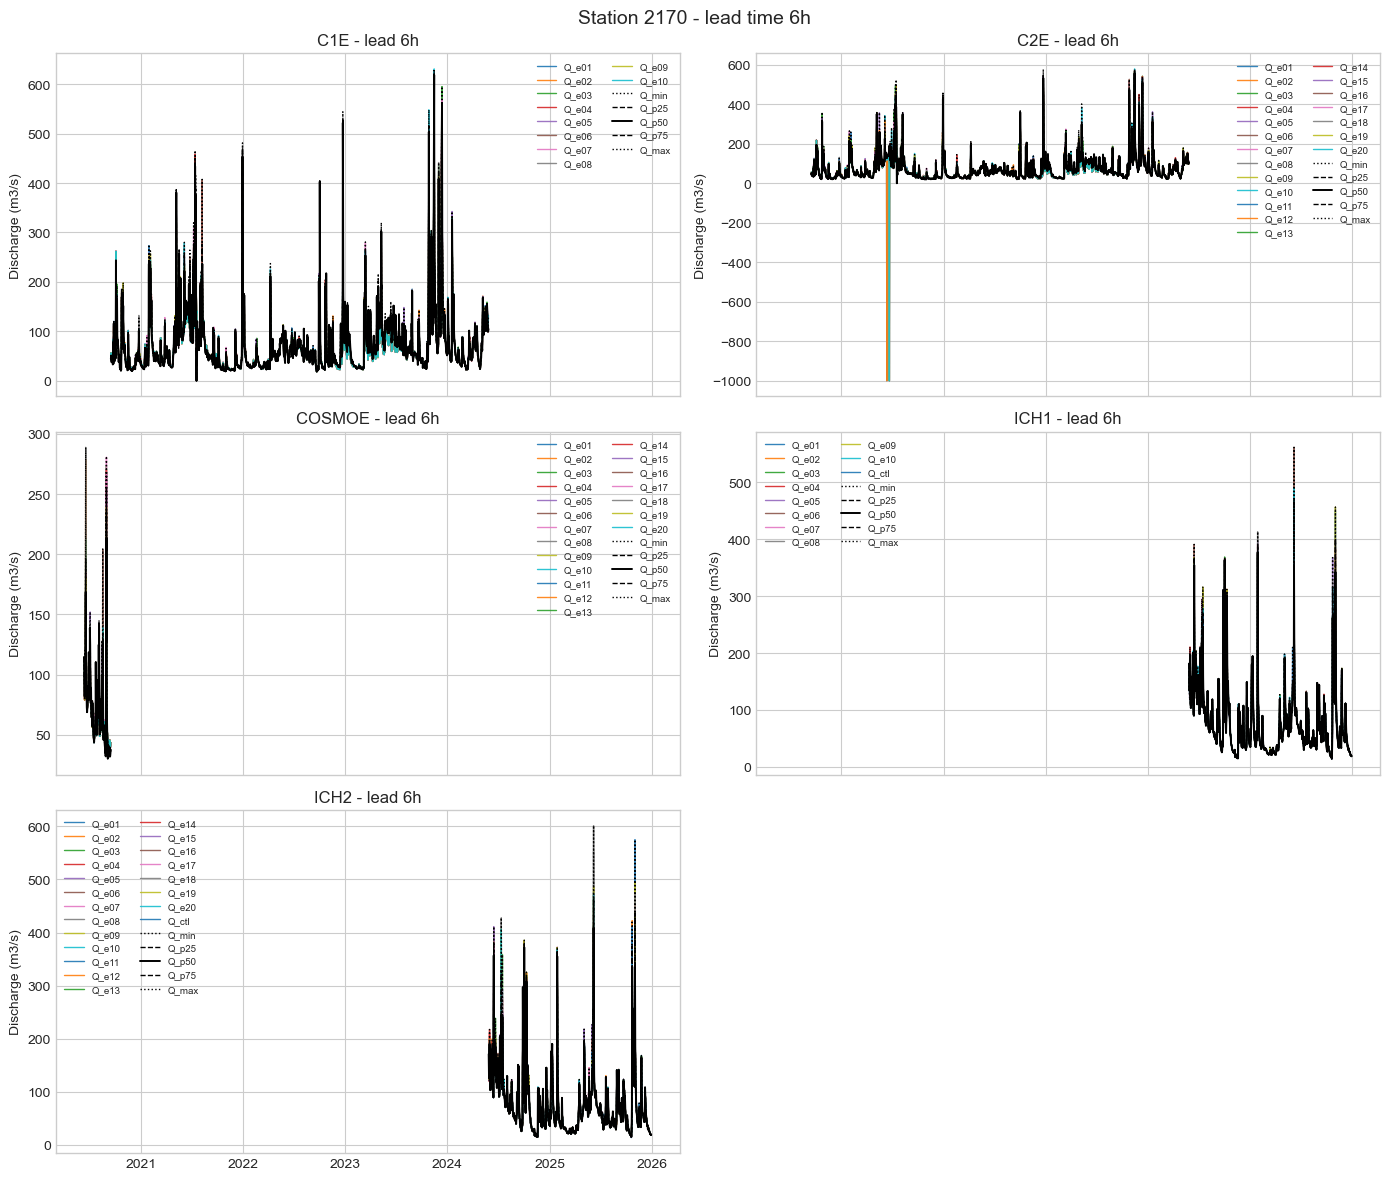

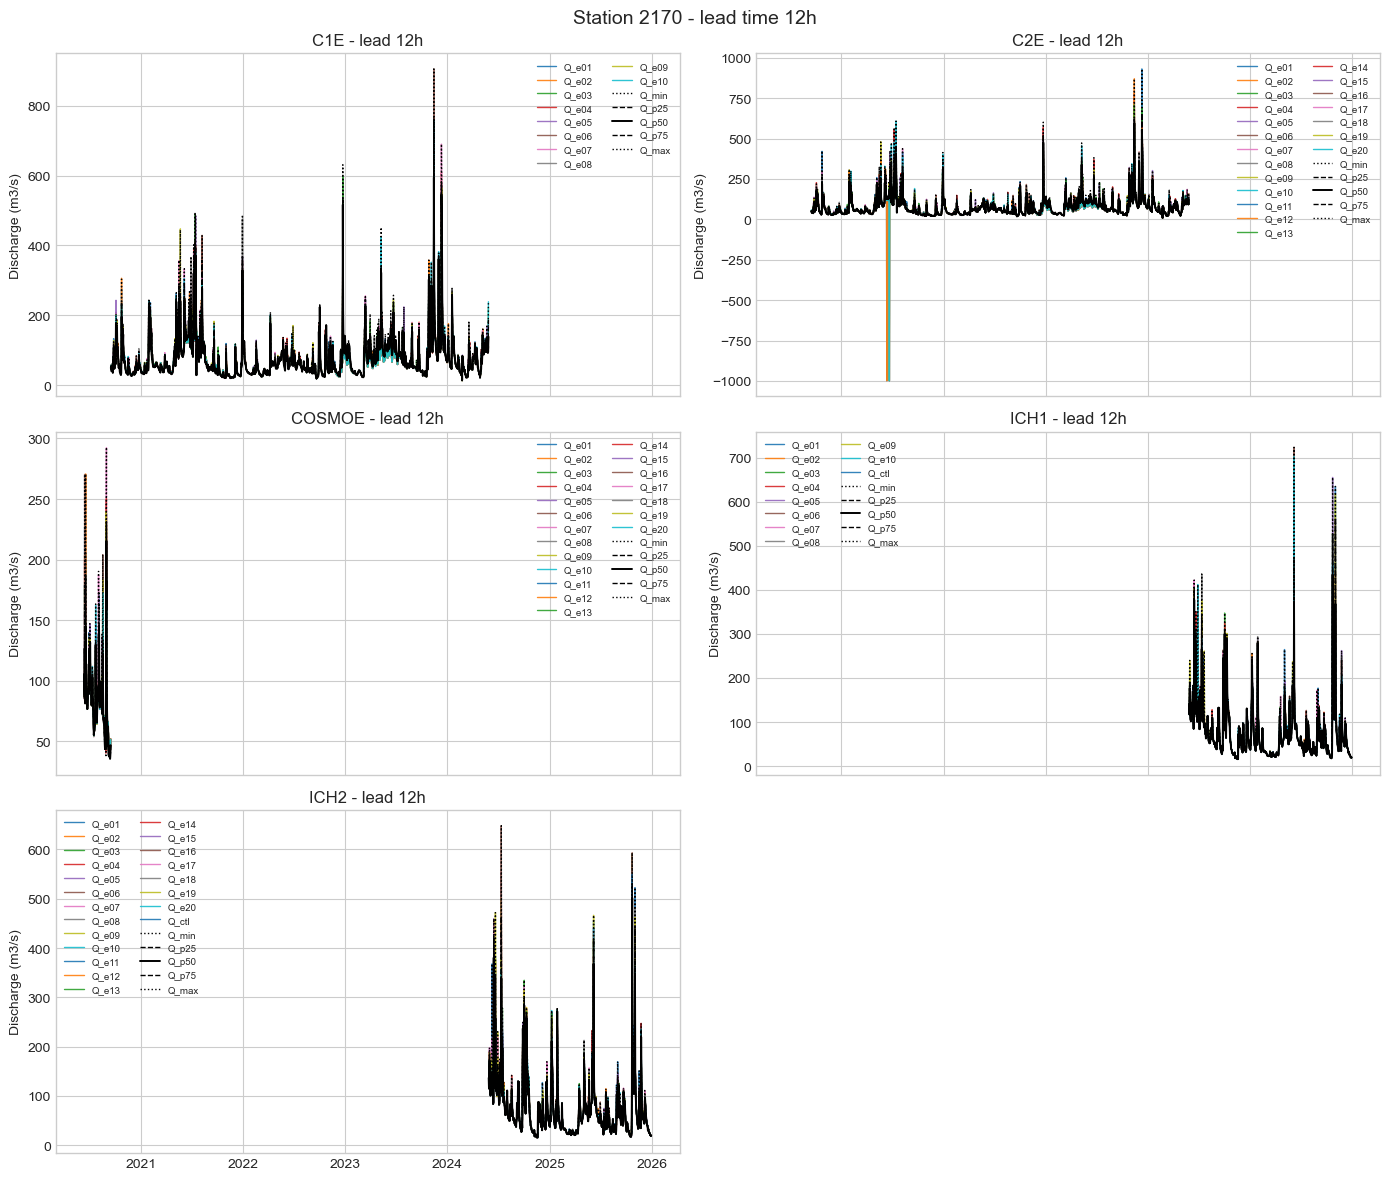

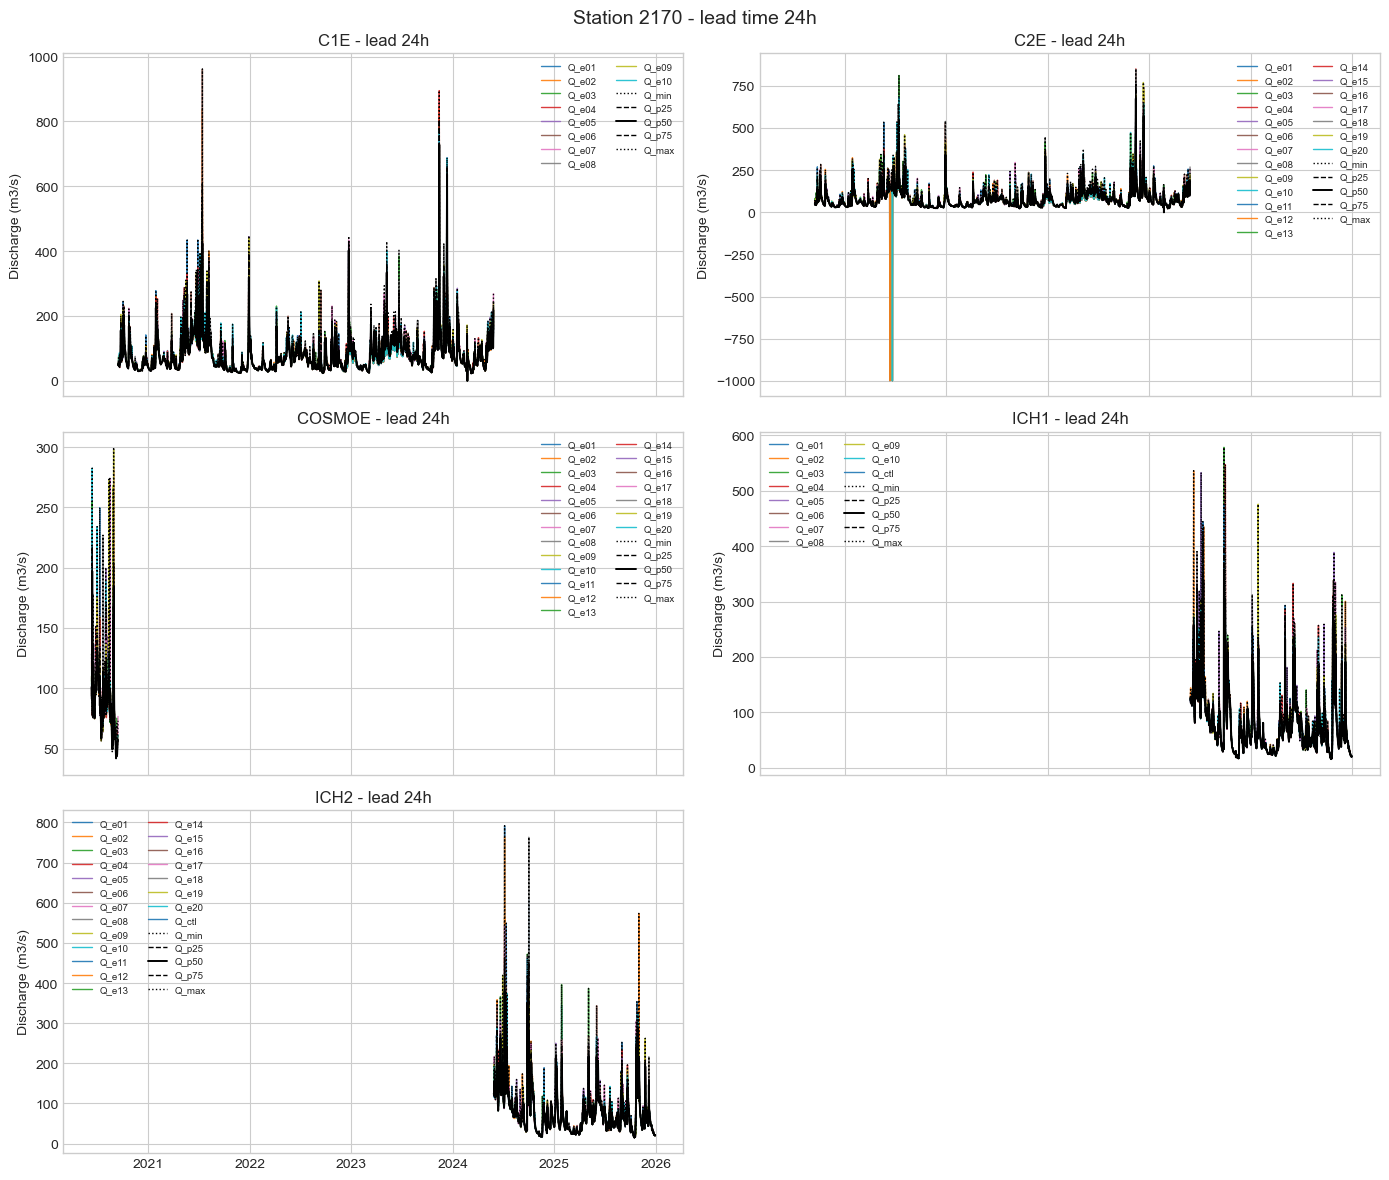

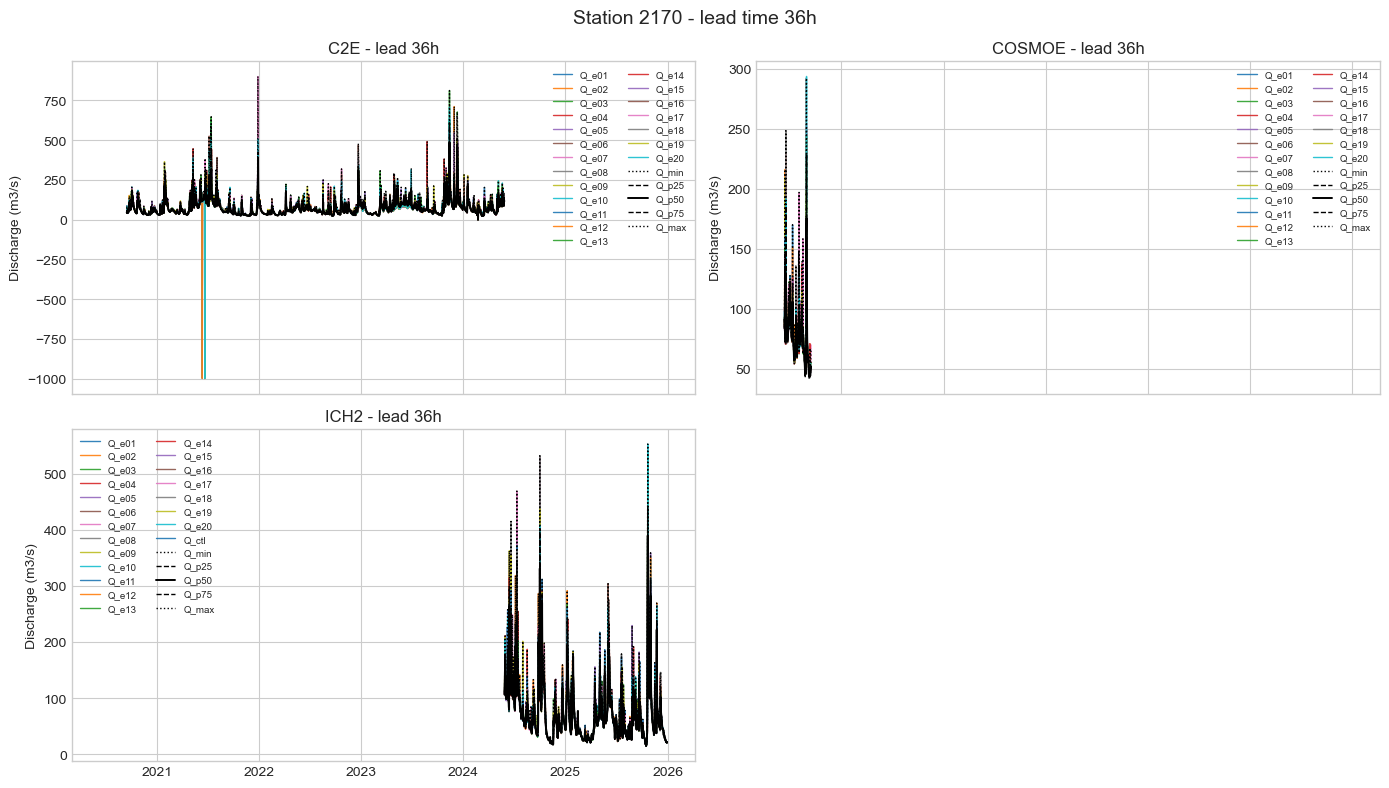

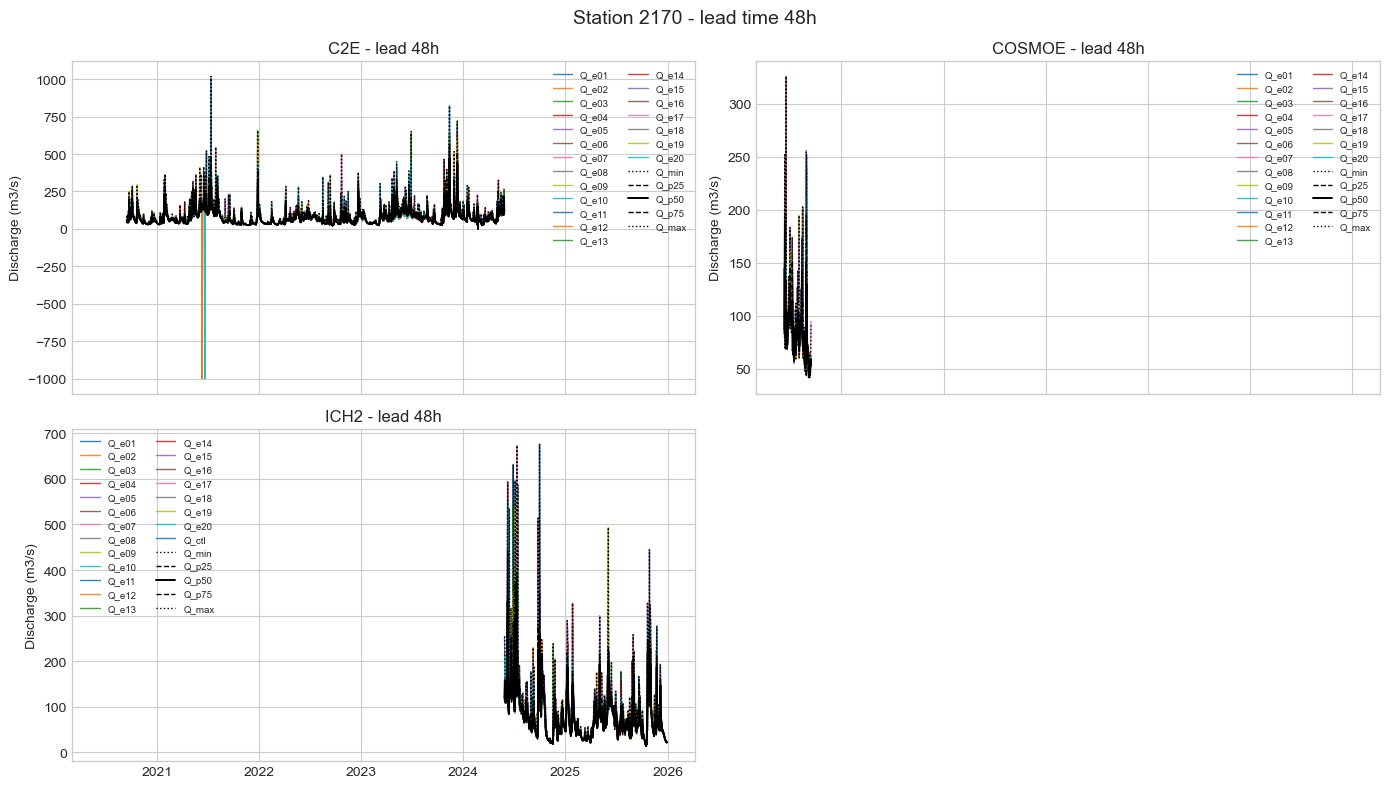

In [14]:
# Same plotting idea as before: for each lead-time, plot all Q members per model + quantile curves.
for lead in LEAD_TIMES:
    dfl = df_ens[df_ens["lead_time_h"] == lead].copy()
    if dfl.empty:
        print(f"No ensemble data for {lead}h")
        continue

    models = sorted(dfl["model"].dropna().unique())
    ncols = 2
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    shown = 0
    for m in models:
        dm = dfl[dfl["model"] == m].sort_values("issue_time")

        # Use only true member columns for this model (Q_ctl, Q_e01, ...), excluding quantile columns.
        member_q_cols = [c for c in dm.columns if re.fullmatch(r"Q_(ctl|e\d{2})", c, flags=re.I) and dm[c].notna().any()]
        if not member_q_cols:
            continue

        ax = axes[shown]
        for c in member_q_cols:
            ax.plot(dm["issue_time"], dm[c], lw=1, alpha=0.9, label=c)

        # Overlay Q quantile envelopes read from file content, if available.
        for c, ls, lw in [("Q_min", ":", 1), ("Q_p25", "--", 1), ("Q_p50", "-", 1.4), ("Q_p75", "--", 1), ("Q_max", ":", 1)]:
            if c in dm.columns and dm[c].notna().any():
                ax.plot(dm["issue_time"], dm[c], linestyle=ls, lw=lw, color="black", label=c)

        ax.set_title(f"{m} - lead {lead}h")
        ax.set_ylabel("Discharge (m3/s)")
        ax.legend(fontsize=7, ncol=2, loc="best")
        shown += 1

    for j in range(shown, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Station {STATION_ID} - lead time {lead}h", fontsize=14)
    fig.tight_layout()
    plt.show()

## Deterministic OFEV per-model benchmark vs OBS, ML, HYD, CNR

This section reruns the same evaluation logic (timeseries, event plots, scatter plots, confusion matrix, and metrics), but **one OFEV deterministic model at a time**.

For each OFEV model and each lead time in `[6, 12, 24, 48]`, all comparisons are restricted to the **time coverage of that OFEV model**. Outputs are saved to `outputs/OFEV_determinist/<OFEV_model>/`.

In [ ]:
import json
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LEAD_TIMES_EVAL = [6, 12, 24, 48]
FLOOD_THR = 400
ROOT = Path("..").resolve()
BASE_DIR = ROOT / "dp_arve"
DATA_DIR = BASE_DIR / "data/Data Fornisseurs"
if not DATA_DIR.exists():
    DATA_DIR = ROOT / "data/Data Fornisseurs"
OUT_BASE = ROOT / "outputs" / "OFEV_determinist"
OUT_BASE.mkdir(parents=True, exist_ok=True)

DET_CSV = ROOT / "outputs" / "OFEV_probabilistic" / "station2170_deterministic.csv"
OBS_PATH = DATA_DIR / "ARVE" / "2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv"
ML_JSON = DATA_DIR / "Hydrique_model" / "Archive prévisions Hydrique ML Arve-Bout du Monde.json"
HYD_JSON = DATA_DIR / "Hydrique_model" / "Archive prévisions Hydrique hydrique-curve Arve-Bout du Monde.json"
CNR_CSV = DATA_DIR / "SIG-CNR_model" / "Previsions_CNR_20_25.csv"
OBS_FALLBACK = ROOT / "data" / "moi" / "observations" / "2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv"
CNR_XLSX_FALLBACK = ROOT / "data" / "moi" / "sig_cnr" / "Prévisions_QArve.xlsx"


def nse(obs, sim):
    den = np.sum((obs - np.mean(obs)) ** 2)
    return np.nan if den == 0 else 1 - np.sum((obs - sim) ** 2) / den


def kge(obs, sim):
    if len(obs) < 2:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    if np.isnan(r) or np.std(obs) == 0 or np.mean(obs) == 0:
        return np.nan
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)


def peak_error(obs, sim):
    m = np.max(obs)
    return np.nan if m == 0 else (np.max(sim) - m) / m * 100


def peak_timing(obs, sim, index):
    return (index[np.argmax(sim)] - index[np.argmax(obs)]).total_seconds() / 3600


def rmse(obs, sim):
    return np.sqrt(np.mean((obs - sim) ** 2))


def relative_volume_error(obs, sim):
    den = np.sum(obs)
    return np.nan if den == 0 else (np.sum(sim) - den) / den * 100


def mape_high_flows(obs, sim, thr):
    mask = obs > thr
    if mask.sum() == 0:
        return np.nan
    den = obs[mask]
    den = np.where(den == 0, np.nan, den)
    return 100 * np.nanmean(np.abs((obs[mask] - sim[mask]) / den))


def get_flood_events(series, thr, gap_hours=12):
    mask = series > thr
    groups = (mask != mask.shift()).cumsum()
    raw = [(g.index.min(), g.index.max()) for _, g in series[mask].groupby(groups)]
    if not raw:
        return []
    merged = [raw[0]]
    for start, end in raw[1:]:
        ps, pe = merged[-1]
        if (start - pe).total_seconds() / 3600 <= gap_hours:
            merged[-1] = (ps, end)
        else:
            merged.append((start, end))
    return merged


def event_confusion_matrix(df, thr):
    obs_events = get_flood_events(df["Q_obs"], thr)
    sim_events = get_flood_events(df.iloc[:, 1], thr)
    tp = fp = fn = 0
    for start, end in obs_events:
        tp += int(df.loc[start:end].iloc[:, 1].max() > thr)
        fn += int(df.loc[start:end].iloc[:, 1].max() <= thr)
    for start, end in sim_events:
        fp += int(df.loc[start:end]["Q_obs"].max() <= thr)
    return tp, fp, fn


def event_scores(tp, fp, fn):
    pod = tp / (tp + fn) if (tp + fn) else np.nan
    far = fp / (tp + fp) if (tp + fp) else np.nan
    csi = tp / (tp + fp + fn) if (tp + fp + fn) else np.nan
    return pod, far, csi


def peak_timing_events(df, thr):
    errs = []
    for start, end in get_flood_events(df["Q_obs"], thr):
        sub = df.loc[start:end]
        if len(sub) < 3 or sub.iloc[:, 1].isna().all():
            continue
        errs.append((sub.index[np.argmax(sub.iloc[:, 1].values)] - sub.index[np.argmax(sub["Q_obs"].values)]).total_seconds() / 3600)
    return np.mean(errs) if errs else np.nan


def plot_confusion_matrix(tp, fp, fn, title, out_file):
    cm = np.array([[0, fp], [fn, tp]])
    total = tp + fp + fn
    cmn = cm / total if total > 0 else cm
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            txt = "NA" if (i == 0 and j == 0) else f"{cm[i, j]}\n({cmn[i, j]:.2f})"
            ax.text(j, i, txt, ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Flood", "Flood"]); ax.set_yticklabels(["No Flood", "Flood"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed"); ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.65)
    plt.tight_layout(); plt.savefig(out_file, dpi=220); plt.close()


def load_obs_hourly(path):
    obs = pd.read_csv(path, sep=";", encoding="cp1252", skiprows=8)
    obs.columns = obs.columns.str.strip()
    obs = obs.rename(columns={"Zeitstempel": "datetime", "Wert": "Q_obs"})
    obs = obs[["datetime", "Q_obs"]]
    obs["datetime"] = pd.to_datetime(obs["datetime"], errors="coerce")
    obs["Q_obs"] = pd.to_numeric(obs["Q_obs"], errors="coerce")
    obs = obs.dropna().drop_duplicates(subset=["datetime"]).sort_values("datetime")
    return obs.set_index("datetime").resample("1h").mean()


def load_hydrique_json(path, q_col):
    with open(path, encoding="utf-8") as f:
        d = json.load(f)
    rec = [(ft, vt, q) for ft, ts in d["ForecastFirstDate2Timeseries"].items() for vt, q in ts.items()]
    df = pd.DataFrame(rec, columns=["forecast_time", "valid_time", q_col])
    df["forecast_time"] = pd.to_datetime(df["forecast_time"], errors="coerce")
    df["valid_time"] = pd.to_datetime(df["valid_time"], errors="coerce")
    df[q_col] = pd.to_numeric(df[q_col], errors="coerce")
    df["lead_time_h"] = (df["valid_time"] - df["forecast_time"]).dt.total_seconds() / 3600
    return df.set_index("valid_time")


def _norm_col(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("ascii").lower()
    return re.sub(r"[^a-z0-9]+", "_", s).strip("_")


def load_cnr_csv(path):
    df = pd.read_csv(path)
    cmap = {c: _norm_col(c) for c in df.columns}
    inv = {v: k for k, v in cmap.items()}

    prev_col = inv.get("datetime_prev")
    valid_col = inv.get("date_prevision")
    q_col = inv.get("q") or inv.get("debit") or inv.get("discharge")

    if prev_col is None or valid_col is None or q_col is None:
        raise ValueError(f"Unexpected CNR columns: {list(df.columns)}")

    out = pd.DataFrame({
        "forecast_time": pd.to_datetime(df[prev_col], errors="coerce"),
        "valid_time": pd.to_datetime(df[valid_col], errors="coerce"),
        "Q_cnr": pd.to_numeric(df[q_col], errors="coerce"),
    })
    out = out.dropna(subset=["valid_time", "Q_cnr"])
    out["lead_time_h"] = (out["valid_time"] - out["forecast_time"]).dt.total_seconds() / 3600
    return out.set_index("valid_time")


def load_cnr_xlsx(path):
    xls = pd.ExcelFile(path)
    best = None
    for sh in xls.sheet_names:
        df = pd.read_excel(path, sheet_name=sh)
        if df.empty:
            continue
        cmap = {c: _norm_col(c) for c in df.columns}
        if {"datetime_prev", "date_prevision"}.issubset(set(cmap.values())):
            inv = {v: k for k, v in cmap.items()}
            out = pd.DataFrame({
                "forecast_time": pd.to_datetime(df[inv["datetime_prev"]], errors="coerce"),
                "valid_time": pd.to_datetime(df[inv["date_prevision"]], errors="coerce"),
                "Q_cnr": pd.to_numeric(df[inv.get("q", inv.get("debit", list(df.columns)[-1]))], errors="coerce"),
            })
        else:
            dt_candidates = [c for c, lc in cmap.items() if any(k in lc for k in ["date", "time", "timestamp", "prevision"])]
            q_candidates = [c for c, lc in cmap.items() if any(k in lc for k in ["debit", "flow", "discharge", "m3", "_q", "q_"]) or lc == "q"]
            if not dt_candidates:
                continue
            dt_col = max(dt_candidates, key=lambda c: pd.to_datetime(df[c], errors="coerce").notna().mean())
            q_col = max((q_candidates or list(df.columns)), key=lambda c: pd.to_numeric(df[c], errors="coerce").notna().mean())
            out = pd.DataFrame({
                "valid_time": pd.to_datetime(df[dt_col], errors="coerce"),
                "Q_cnr": pd.to_numeric(df[q_col], errors="coerce"),
            })
            out["forecast_time"] = out["valid_time"]

        out = out.dropna(subset=["valid_time", "Q_cnr"])
        out["lead_time_h"] = (out["valid_time"] - out["forecast_time"]).dt.total_seconds() / 3600
        out = out.set_index("valid_time")
        if best is None or len(out) > len(best):
            best = out

    return best if best is not None else pd.DataFrame(columns=["forecast_time", "Q_cnr", "lead_time_h"])


def clean_q_frame(df, col):
    out = df[[col]].copy()
    out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.dropna(subset=[col])
    out = out[out[col] >= 0]
    return out.sort_index()


def safe_name(s):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")


def infer_problem_reasons(obs_v, sim_v, tp, fp, fn, nse_v, kge_v, rmse_v, pod, far, csi, has_enough_high):
    reasons = []

    if pd.isna(nse_v):
        den = np.sum((obs_v - np.mean(obs_v)) ** 2)
        reasons.append("ZERO_OBS_VARIANCE" if den == 0 else "NSE_UNDEFINED")

    if pd.isna(kge_v):
        if len(obs_v) < 2:
            reasons.append("TOO_FEW_POINTS")
        if np.std(obs_v) == 0:
            reasons.append("ZERO_OBS_VARIANCE")
        if np.mean(obs_v) == 0:
            reasons.append("ZERO_OBS_MEAN")
        if len(obs_v) >= 2 and np.isnan(np.corrcoef(obs_v, sim_v)[0, 1]):
            reasons.append("UNDEFINED_CORRELATION")
        if not reasons:
            reasons.append("KGE_UNDEFINED")

    if pd.isna(rmse_v):
        reasons.append("RMSE_UNDEFINED")

    if pd.isna(pod) and (tp + fn) == 0:
        reasons.append("NO_OBS_EVENTS")
    if pd.isna(far) and (tp + fp) == 0:
        reasons.append("NO_SIM_EVENTS")
    if pd.isna(csi) and (tp + fp + fn) == 0:
        reasons.append("NO_EVENTS_ANY")

    if not has_enough_high:
        reasons.append("TOO_FEW_HIGH_FLOW_POINTS")

    return "|".join(dict.fromkeys(reasons))


# ---------------------- Load all inputs once ----------------------
if not OBS_PATH.exists() and OBS_FALLBACK.exists():
    OBS_PATH = OBS_FALLBACK

print(f"Using DATA_DIR: {DATA_DIR}")
print(f"Using OBS path: {OBS_PATH}")
print(f"Using CNR source: {CNR_CSV if CNR_CSV.exists() else CNR_XLSX_FALLBACK}")
obs_h = load_obs_hourly(OBS_PATH)
ml = load_hydrique_json(ML_JSON, "Q_ml")
hyd = load_hydrique_json(HYD_JSON, "Q_hyd")
cnr = load_cnr_csv(CNR_CSV) if CNR_CSV.exists() else load_cnr_xlsx(CNR_XLSX_FALLBACK)

ofev_det = pd.read_csv(DET_CSV, parse_dates=["issue_time", "valid_time"])
ofev_det["lead_time_h"] = pd.to_numeric(ofev_det["lead_time_h"], errors="coerce")
ofev_det["Q"] = pd.to_numeric(ofev_det["Q"], errors="coerce")
ofev_det = ofev_det.dropna(subset=["model", "valid_time", "Q", "lead_time_h"])
ofev_det = ofev_det[ofev_det["Q"] >= 0]
ofev_det = ofev_det.set_index("valid_time")

all_rows = []

for ofev_model in sorted(ofev_det["model"].astype(str).unique()):
    model_dir = OUT_BASE / safe_name(ofev_model)
    cm_dir = model_dir / "Confusion Matrix"
    model_dir.mkdir(parents=True, exist_ok=True)
    cm_dir.mkdir(parents=True, exist_ok=True)

    event_totals = {"OFEV": np.array([0, 0, 0]), "Hydrique_ML": np.array([0, 0, 0]), "Hydrique_Curve": np.array([0, 0, 0]), "SIG_CNR": np.array([0, 0, 0])}
    model_metrics = []

    for lt in LEAD_TIMES_EVAL:
        out_lt = model_dir / f"leadtime_{lt}h"
        out_lt.mkdir(parents=True, exist_ok=True)

        ofev_lt = ofev_det[(ofev_det["model"].astype(str) == ofev_model) & (ofev_det["lead_time_h"].round().astype(int) == lt)][["Q"]].rename(columns={"Q": "Q_ofev"})
        ofev_lt = ofev_lt.groupby(ofev_lt.index).median().sort_index()
        ofev_lt = clean_q_frame(ofev_lt, "Q_ofev")
        if ofev_lt.empty:
            continue

        # Restrict all comparisons strictly to this OFEV model coverage.
        t0, t1 = ofev_lt.index.min(), ofev_lt.index.max()
        obs_plot = clean_q_frame(obs_h.loc[t0:t1], "Q_obs")
        ml_plot = clean_q_frame(ml[ml["lead_time_h"].round() == lt][["Q_ml"]].loc[t0:t1], "Q_ml")
        hyd_plot = clean_q_frame(hyd[hyd["lead_time_h"].round() == lt][["Q_hyd"]].loc[t0:t1], "Q_hyd")
        cnr_plot = clean_q_frame(cnr[cnr["lead_time_h"].round() == lt][["Q_cnr"]].loc[t0:t1], "Q_cnr")
        if obs_plot.empty:
            continue

        # Timeseries plot on OFEV-model-specific period.
        plt.figure(figsize=(16, 6))
        plt.plot(obs_plot.index, obs_plot["Q_obs"], color="black", label="Observed")
        if not ml_plot.empty: plt.plot(ml_plot.index, ml_plot["Q_ml"], label="Hydrique ML")
        if not hyd_plot.empty: plt.plot(hyd_plot.index, hyd_plot["Q_hyd"], label="Hydrique Curve")
        if not cnr_plot.empty: plt.plot(cnr_plot.index, cnr_plot["Q_cnr"], label="SIG-CNR")
        plt.plot(ofev_lt.index, ofev_lt["Q_ofev"], label=f"OFEV {ofev_model}")
        plt.xlim(t0, t1); plt.legend(); plt.title(f"{ofev_model} - Timeseries LT {lt}h")
        plt.tight_layout(); plt.savefig(out_lt / f"timeseries_LT{lt}.png", dpi=200); plt.close()

        # Event windows plot (OBS events only, expanded +-2 days).
        for i, (start, end) in enumerate(get_flood_events(obs_plot["Q_obs"], FLOOD_THR)):
            sw, ew = start - pd.Timedelta(days=2), end + pd.Timedelta(days=2)
            fig, ax = plt.subplots(figsize=(16, 6))
            ax.plot(obs_plot.loc[sw:ew].index, obs_plot.loc[sw:ew, "Q_obs"], color="black", label="Observed")
            if not ml_plot.empty: ax.plot(ml_plot.loc[sw:ew].index, ml_plot.loc[sw:ew, "Q_ml"], label="Hydrique ML")
            if not hyd_plot.empty: ax.plot(hyd_plot.loc[sw:ew].index, hyd_plot.loc[sw:ew, "Q_hyd"], label="Hydrique Curve")
            if not cnr_plot.empty: ax.plot(cnr_plot.loc[sw:ew].index, cnr_plot.loc[sw:ew, "Q_cnr"], label="SIG-CNR")
            ax.plot(ofev_lt.loc[sw:ew].index, ofev_lt.loc[sw:ew, "Q_ofev"], label=f"OFEV {ofev_model}")
            ax.set_xlim(sw, ew)
            ax.set_title(f"{ofev_model} flood {sw.strftime('%d/%m')} - {ew.strftime('%d/%m/%Y')} (LT {lt}h)")
            ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d/%m\n%H:%M"))
            ax.legend(); plt.tight_layout()
            plt.savefig(out_lt / f"flood_{sw.strftime('%Y%m%d')}_{ew.strftime('%Y%m%d')}_LT{lt}_{i+1:02d}.png", dpi=200)
            plt.close()

        # Metrics for each compared model on the same OFEV-model period.
        for name, s in [("OFEV", ofev_lt), ("Hydrique_ML", ml_plot), ("Hydrique_Curve", hyd_plot), ("SIG_CNR", cnr_plot)]:
            df = obs_plot.join(s, how="inner").dropna()
            df = df[(df["Q_obs"] >= 0) & (df.iloc[:, 1] >= 0)]
            if len(df) < 10:
                continue

            obs_v, sim_v = df["Q_obs"].values, df.iloc[:, 1].values
            df_high = df[df["Q_obs"] > FLOOD_THR]
            obs_hf, sim_hf = (df_high["Q_obs"].values, df_high.iloc[:, 1].values) if len(df_high) > 5 else (None, None)
            has_enough_high = len(df_high) > 5

            tp, fp, fn = event_confusion_matrix(df, FLOOD_THR)
            pod, far, csi = event_scores(tp, fp, fn)
            event_totals[name] += np.array([tp, fp, fn])
            plot_confusion_matrix(tp, fp, fn, f"{ofev_model} | {name} - LT{lt}", cm_dir / f"CM_{name}_LT{lt}.png")

            reqs, tps, rers = [], [], []
            for start, end in get_flood_events(df["Q_obs"], FLOOD_THR):
                de = df.loc[start - pd.Timedelta(days=2): end + pd.Timedelta(days=2)]
                de = de.dropna()
                de = de[(de["Q_obs"] >= 0) & (de.iloc[:, 1] >= 0)]
                if len(de) < 5:
                    continue
                reqs.append(peak_error(de["Q_obs"].values, de.iloc[:, 1].values))
                tps.append(peak_timing(de["Q_obs"].values, de.iloc[:, 1].values, de.index))
                rers.append(relative_volume_error(de["Q_obs"].values, de.iloc[:, 1].values))

            nse_v = nse(obs_v, sim_v)
            kge_v = kge(obs_v, sim_v)
            rmse_v = rmse(obs_v, sim_v)
            mape_v = mape_high_flows(obs_v, sim_v, FLOOD_THR)
            nse_high_v = nse(obs_hf, sim_hf) if obs_hf is not None else np.nan
            kge_high_v = kge(obs_hf, sim_hf) if obs_hf is not None else np.nan
            rmse_high_v = rmse(obs_hf, sim_hf) if obs_hf is not None else np.nan
            req_high_v = peak_error(obs_hf, sim_hf) if obs_hf is not None else np.nan
            tp_high_v = peak_timing_events(df, FLOOD_THR)
            rer_high_v = relative_volume_error(obs_hf, sim_hf) if obs_hf is not None else np.nan
            problem_reason = infer_problem_reasons(obs_v, sim_v, tp, fp, fn, nse_v, kge_v, rmse_v, pod, far, csi, has_enough_high)
            coverage_start = df.index.min().isoformat()
            coverage_end = df.index.max().isoformat()

            model_metrics.append({
                "ofev_model": ofev_model,
                "lead_time": lt,
                "model": name,
                "N_rows": len(df),
                "coverage_start": coverage_start,
                "coverage_end": coverage_end,
                "NSE": nse_v,
                "KGE": kge_v,
                "RMSE": rmse_v,
                "REQ_%": np.median(reqs) if reqs else np.nan,
                "TP_h": np.median(tps) if tps else np.nan,
                "RER_%": np.median(rers) if rers else np.nan,
                "MAPE_high_%": mape_v,
                "POD": pod,
                "FAR": far,
                "CSI": csi,
                "NSE_high": nse_high_v,
                "KGE_high": kge_high_v,
                "RMSE_high": rmse_high_v,
                "REQ_high_%": req_high_v,
                "TP_high_h": tp_high_v,
                "RER_high_%": rer_high_v,
                "problem_reason": problem_reason,
            })

            # Scatter on exactly the same rows used for metrics.
            plt.figure(figsize=(5, 5))
            plt.scatter(obs_v, sim_v, s=5, alpha=0.3)
            mmax = max(np.nanmax(obs_v), np.nanmax(sim_v))
            plt.plot([0, mmax], [0, mmax], "k--")
            plt.xlabel("Observed"); plt.ylabel(name)
            plt.title(f"{ofev_model} - {name} LT{lt}")
            plt.tight_layout(); plt.savefig(out_lt / f"scatter_{name}_LT{lt}.png", dpi=200); plt.close()

    for name, vals in event_totals.items():
        tp, fp, fn = vals
        plot_confusion_matrix(tp, fp, fn, f"{ofev_model} | {name} - ALL_LT", cm_dir / f"CM_{name}_ALL_LT.png")

    model_metrics = pd.DataFrame(model_metrics)
    model_metrics.to_csv(model_dir / "metrics_all_models.csv", index=False)
    all_rows.append(model_metrics)

summary = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
summary.to_csv(OUT_BASE / "metrics_all_models_summary.csv", index=False)

if not summary.empty:
    problem_cols = ["NSE", "KGE", "RMSE", "POD", "FAR", "CSI"]
    bad = summary[summary[problem_cols].isna().any(axis=1)].copy()
    if not bad.empty:
        print(f"Problematic lines in summary: {len(bad)}")
        print(bad[["ofev_model", "lead_time", "model", "N_rows", "coverage_start", "coverage_end", *problem_cols, "problem_reason"]].to_string(index=False))

print("Done. OFEV deterministic comparison outputs in:", OUT_BASE)
print("Folders created:", len([p for p in OUT_BASE.iterdir() if p.is_dir()]))
display(summary.head())

Using DATA_DIR: C:\Users\simon\Documents\DP\analysis\data\Data Fornisseurs
Using OBS path: C:\Users\simon\Documents\DP\analysis\data\Data Fornisseurs\ARVE\2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv
Using CNR source: C:\Users\simon\Documents\DP\analysis\data\moi\sig_cnr\Prévisions_QArve.xlsx
Problematic lines in summary: 100
ofev_model  lead_time          model  N_rows      coverage_start        coverage_end       NSE      KGE      RMSE  POD  FAR  CSI                                                     problem_reason
    COSMO1          6           OFEV     120 2020-06-11T12:00:00 2020-09-14T10:00:00  0.872517 0.865520 12.114990  NaN  NaN  NaN NO_OBS_EVENTS|NO_SIM_EVENTS|NO_EVENTS_ANY|TOO_FEW_HIGH_FLOW_POINTS
    COSMO1          6    Hydrique_ML     182 2020-06-11T12:00:00 2020-09-14T00:00:00  0.719663 0.777427 14.241108  NaN  NaN  NaN NO_OBS_EVENTS|NO_SIM_EVENTS|NO_EVENTS_ANY|TOO_FEW_HIGH_FLOW_POINTS
    COSMO1          6 Hydrique_Curve     180 2020-06-11T12:00:00 2020-09-14T

,ofev_model,lead_time,model,N_rows,coverage_start,coverage_end,NSE,KGE,RMSE,REQ_%,...,POD,FAR,CSI,NSE_high,KGE_high,RMSE_high,REQ_high_%,TP_high_h,RER_high_%,problem_reason
0,C1E_Ctrl,6,OFEV,1676,2020-09-15T13:00:00,2024-05-27T11:00:00,0.900292,0.871247,23.022394,-14.263526,...,0.666667,0.000,0.666667,0.050576,0.430072,118.317302,-37.452789,0.0,-14.341155,
1,C1E_Ctrl,6,Hydrique_ML,2639,2020-09-16T00:00:00,2024-05-27T00:00:00,0.814997,0.847107,26.966181,-32.619751,...,0.333333,0.250,0.300000,-1.878514,0.452488,198.091879,-33.758104,-8.0,-33.043833,
2,C1E_Ctrl,6,Hydrique_Curve,2641,2020-09-16T00:00:00,2024-05-27T00:00:00,0.938707,0.964906,15.480284,-5.035925,...,0.777778,0.125,0.700000,0.674652,0.700202,66.597241,2.714201,-8.0,-3.414572,
3,C1E_Ctrl,12,OFEV,1676,2020-09-15T19:00:00,2024-05-27T17:00:00,0.853057,0.855395,27.196405,-15.476626,...,0.375000,0.000,0.375000,-5.285382,-0.378932,168.170210,11.886909,-16.0,-21.544115,
4,C1E_Ctrl,12,Hydrique_ML,2639,2020-09-16T06:00:00,2024-05-27T06:00:00,0.800351,0.838510,28.073480,-34.446987,...,0.625000,0.000,0.625000,-1.091389,0.328187,211.194900,-47.968738,0.0,-30.633479,


In [ ]:
df_det.head()